In [1]:
from scipy.signal import envelope, hilbert
import scipy.io as sio
import pandas as pd
import numpy as np
import sys, os
import torch
import numpy.random as random
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from data_classes.decomposition import Extract_Features

In [32]:
phase1_data = sio.loadmat('../data/mine_impact_data_2019.mat')
samples  = pd.DataFrame(phase1_data["x"].T)
labels  = pd.DataFrame(phase1_data["y"].T, columns=["y"])

df = pd.concat([samples, labels], axis=1, join="inner")

df = df.dropna()

In [33]:
shuffled_df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df_X = shuffled_df.iloc[:, :-1]
df_Y = shuffled_df.iloc[:, -1]


In [47]:

##envelope + rms
data = Extract_Features(
    df_X=df_X,
    df_Y=df_Y,
    feature = "amplitude_envelope",
    frame_size = 128,
    hop_length = 32
)

data_rms = Extract_Features(
    df_X=df_X,
    df_Y=df_Y,
    feature = "rms_energy",
    frame_size = 128,
    hop_length = 32
)
data.X_reduced = np.concatenate((data.X_reduced, data_rms.X_reduced), axis=1)

print(data.get_samples().shape)
print(data.get_labels().shape)

(3309, 2248)
(3309,)


In [48]:
torch.manual_seed(42)

In [51]:
import models.classification as classify
import models.loops as loops

train_idx = list(range(0, 3000))
test_idx = list(range(3000,3309))

train_data = torch.utils.data.Subset(data, train_idx)
test_data = torch.utils.data.Subset(data, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

model = classify.MLP_3_layer(nb_hidden=512, input_dim=data.get_samples().shape[1], output_dim=2, dropout_rate=0.5)

loops.train(model=model, model_path="./model_paths/concat_env_rms.pth", train_loader=train_loader, batch_size=batch_size, lr=1e-3, weight_decay=1e-2, optim="adam", epochs=20)

loops.test(model_path="./model_paths/concat_env_rms.pth", test_loader=test_loader)

[INFO] EPOCH: 1/20
Train loss: 0.571869, Train accuracy: 0.6653
[INFO] EPOCH: 2/20
Train loss: 0.510029, Train accuracy: 0.7207
[INFO] EPOCH: 3/20
Train loss: 0.476024, Train accuracy: 0.7460
[INFO] EPOCH: 4/20
Train loss: 0.476012, Train accuracy: 0.7553
[INFO] EPOCH: 5/20
Train loss: 0.455415, Train accuracy: 0.7647
[INFO] EPOCH: 6/20
Train loss: 0.442904, Train accuracy: 0.7730
[INFO] EPOCH: 7/20
Train loss: 0.447350, Train accuracy: 0.7717
[INFO] EPOCH: 8/20
Train loss: 0.413857, Train accuracy: 0.7967
[INFO] EPOCH: 9/20
Train loss: 0.411435, Train accuracy: 0.7963
[INFO] EPOCH: 10/20
Train loss: 0.387262, Train accuracy: 0.8247
[INFO] EPOCH: 11/20
Train loss: 0.369376, Train accuracy: 0.8283
[INFO] EPOCH: 12/20
Train loss: 0.372493, Train accuracy: 0.8190
[INFO] EPOCH: 13/20
Train loss: 0.332204, Train accuracy: 0.8493
[INFO] EPOCH: 14/20
Train loss: 0.342644, Train accuracy: 0.8377
[INFO] EPOCH: 15/20
Train loss: 0.334868, Train accuracy: 0.8500
[INFO] EPOCH: 16/20
Train loss: 0.

In [52]:
torch.manual_seed(42)

In [53]:
##envelope + zcr
data = Extract_Features(
    df_X=df_X,
    df_Y=df_Y,
    feature = "amplitude_envelope",
    frame_size = 128,
    hop_length = 32
)

data_zcr = Extract_Features(
    df_X=df_X,
    df_Y=df_Y,
    feature = "zero_crossing_rate",
    frame_size = 128,
    hop_length = 32
)
data.X_reduced = np.concatenate((data.X_reduced, data_zcr.X_reduced), axis=1)

print(data.get_samples().shape)
print(data.get_labels().shape)

(3309, 2248)
(3309,)


In [57]:
import models.classification as classify
import models.loops as loops

train_idx = list(range(0, 3000))
test_idx = list(range(3000,3309))

train_data = torch.utils.data.Subset(data, train_idx)
test_data = torch.utils.data.Subset(data, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

model = classify.MLP_3_layer(nb_hidden=512, input_dim=data.get_samples().shape[1], output_dim=2, dropout_rate=0.5)

loops.train(model=model, model_path="./model_paths/env_zcr.pth", train_loader=train_loader, batch_size=batch_size, lr=1e-3, weight_decay=1e-2, optim="adam", epochs=20)

loops.test(model_path="./model_paths/env_zcr.pth", test_loader=test_loader)

[INFO] EPOCH: 1/20
Train loss: 0.518720, Train accuracy: 0.7407
[INFO] EPOCH: 2/20
Train loss: 0.428367, Train accuracy: 0.7990
[INFO] EPOCH: 3/20
Train loss: 0.392323, Train accuracy: 0.8153
[INFO] EPOCH: 4/20
Train loss: 0.377151, Train accuracy: 0.8247
[INFO] EPOCH: 5/20
Train loss: 0.347513, Train accuracy: 0.8363
[INFO] EPOCH: 6/20
Train loss: 0.328790, Train accuracy: 0.8443
[INFO] EPOCH: 7/20
Train loss: 0.313769, Train accuracy: 0.8530
[INFO] EPOCH: 8/20
Train loss: 0.281900, Train accuracy: 0.8633
[INFO] EPOCH: 9/20
Train loss: 0.247596, Train accuracy: 0.8893
[INFO] EPOCH: 10/20
Train loss: 0.235537, Train accuracy: 0.8997
[INFO] EPOCH: 11/20
Train loss: 0.204300, Train accuracy: 0.9090
[INFO] EPOCH: 12/20
Train loss: 0.185450, Train accuracy: 0.9173
[INFO] EPOCH: 13/20
Train loss: 0.176867, Train accuracy: 0.9237
[INFO] EPOCH: 14/20
Train loss: 0.163189, Train accuracy: 0.9277
[INFO] EPOCH: 15/20
Train loss: 0.163064, Train accuracy: 0.9313
[INFO] EPOCH: 16/20
Train loss: 0.

In [61]:
##rms + zcr
data = Extract_Features(
    df_X=df_X,
    df_Y=df_Y,
    feature = "rms_energy",
    frame_size = 128,
    hop_length = 32
)

data_zcr = Extract_Features(
    df_X=df_X,
    df_Y=df_Y,
    feature = "zero_crossing_rate",
    frame_size = 128,
    hop_length = 32
)
data.X_reduced = np.concatenate((data.X_reduced, data_zcr.X_reduced), axis=1)

print(data.get_samples().shape)
print(data.get_labels().shape)

(3309, 2252)
(3309,)


In [62]:
torch.manual_seed(42)

In [65]:
import models.classification as classify
import models.loops as loops

train_idx = list(range(0, 3000))
test_idx = list(range(3000,3309))

train_data = torch.utils.data.Subset(data, train_idx)
test_data = torch.utils.data.Subset(data, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

model = classify.MLP_3_layer(nb_hidden=512, input_dim=data.get_samples().shape[1], output_dim=2, dropout_rate=0.5)

loops.train(model=model, model_path="./model_paths/rms_zcr.pth", train_loader=train_loader, batch_size=batch_size, lr=1e-3, weight_decay=1e-2, optim="adam", epochs=20)

loops.test(model_path="./model_paths/rms_zcr.pth", test_loader=test_loader)

[INFO] EPOCH: 1/20
Train loss: 0.535146, Train accuracy: 0.7283
[INFO] EPOCH: 2/20
Train loss: 0.432101, Train accuracy: 0.7963
[INFO] EPOCH: 3/20
Train loss: 0.401063, Train accuracy: 0.8157
[INFO] EPOCH: 4/20
Train loss: 0.364765, Train accuracy: 0.8267
[INFO] EPOCH: 5/20
Train loss: 0.356209, Train accuracy: 0.8337
[INFO] EPOCH: 6/20
Train loss: 0.349549, Train accuracy: 0.8353
[INFO] EPOCH: 7/20
Train loss: 0.340732, Train accuracy: 0.8390
[INFO] EPOCH: 8/20
Train loss: 0.316950, Train accuracy: 0.8540
[INFO] EPOCH: 9/20
Train loss: 0.272988, Train accuracy: 0.8797
[INFO] EPOCH: 10/20
Train loss: 0.252502, Train accuracy: 0.8903
[INFO] EPOCH: 11/20
Train loss: 0.230980, Train accuracy: 0.8960
[INFO] EPOCH: 12/20
Train loss: 0.232514, Train accuracy: 0.8937
[INFO] EPOCH: 13/20
Train loss: 0.216835, Train accuracy: 0.9020
[INFO] EPOCH: 14/20
Train loss: 0.184308, Train accuracy: 0.9273
[INFO] EPOCH: 15/20
Train loss: 0.177540, Train accuracy: 0.9220
[INFO] EPOCH: 16/20
Train loss: 0.

In [66]:
##envelope + rms + zcr
data = Extract_Features(
    df_X=df_X,
    df_Y=df_Y,
    feature = "amplitude_envelope",
    frame_size = 128,
    hop_length = 32
)

data_zcr = Extract_Features(
    df_X=df_X,
    df_Y=df_Y,
    feature = "zero_crossing_rate",
    frame_size = 128,
    hop_length = 32
)

data_rms = Extract_Features(
    df_X=df_X,
    df_Y=df_Y,
    feature = "rms_energy",
    frame_size = 128,
    hop_length = 32
)
data.X_reduced = np.concatenate((data.X_reduced, data_zcr.X_reduced, data_rms.X_reduced), axis=1)

print(data.get_samples().shape)
print(data.get_labels().shape)

(3309, 3374)
(3309,)


In [73]:
torch.manual_seed(42)

In [74]:
import models.classification as classify
import models.loops as loops

train_idx = list(range(0, 3000))
test_idx = list(range(3000,3309))

train_data = torch.utils.data.Subset(data, train_idx)
test_data = torch.utils.data.Subset(data, test_idx)

batch_size = 30

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=True)

model = classify.MLP_3_layer(nb_hidden=1024, input_dim=data.get_samples().shape[1], output_dim=2, dropout_rate=0.5)

loops.train(model=model, model_path="./model_paths/comb.pth", train_loader=train_loader, batch_size=batch_size, lr=1e-3, weight_decay=1e-2, optim="adam", epochs=20)

loops.test(model_path="./model_paths/comb.pth", test_loader=test_loader)

[INFO] EPOCH: 1/20
Train loss: 0.508702, Train accuracy: 0.7490
[INFO] EPOCH: 2/20
Train loss: 0.431232, Train accuracy: 0.7857
[INFO] EPOCH: 3/20
Train loss: 0.386356, Train accuracy: 0.8190
[INFO] EPOCH: 4/20
Train loss: 0.361457, Train accuracy: 0.8227
[INFO] EPOCH: 5/20
Train loss: 0.325691, Train accuracy: 0.8377
[INFO] EPOCH: 6/20
Train loss: 0.308309, Train accuracy: 0.8517
[INFO] EPOCH: 7/20
Train loss: 0.276685, Train accuracy: 0.8717
[INFO] EPOCH: 8/20
Train loss: 0.260206, Train accuracy: 0.8667
[INFO] EPOCH: 9/20
Train loss: 0.231027, Train accuracy: 0.9000
[INFO] EPOCH: 10/20
Train loss: 0.205098, Train accuracy: 0.9123
[INFO] EPOCH: 11/20
Train loss: 0.187469, Train accuracy: 0.9263
[INFO] EPOCH: 12/20
Train loss: 0.201452, Train accuracy: 0.9080
[INFO] EPOCH: 13/20
Train loss: 0.175498, Train accuracy: 0.9230
[INFO] EPOCH: 14/20
Train loss: 0.156992, Train accuracy: 0.9357
[INFO] EPOCH: 15/20
Train loss: 0.145961, Train accuracy: 0.9393
[INFO] EPOCH: 16/20
Train loss: 0.

In [2]:
import plotly.express as px

phase1 = sio.loadmat('../data/mine_impact_data_2019.mat')
X_df    = pd.DataFrame(phase1["x"].T)
y_df    = pd.DataFrame(phase1["y"].T, columns=["y"])
mine_df = pd.DataFrame(phase1["mine"].T, columns=["mine"])
df = pd.concat([X_df, y_df, mine_df], axis=1).dropna().reset_index(drop=True)

df = df.dropna()

In [ ]:
import models.classification as classify
import models.loops as loops
results = []
mines = sorted(df["mine"].unique())
features = ["amplitude_envelope","zero_crossing_rate","rms_energy"]
fs, hop = 128, 32

for test_mine in mines:
    df_train = df[df["mine"] != test_mine].reset_index(drop=True)
    df_test  = df[df["mine"] == test_mine].reset_index(drop=True)

    # instantiate with keyword args for frame_size & hop_length
    trains = [
        Extract_Features(
            df_X=df_train.iloc[:, :-2],
            df_Y=df_train[["y"]],
            feature=f,
            frame_size=fs,
            hop_length=hop
        )
        for f in features
    ]
    tests = [
        Extract_Features(
            df_X=df_test.iloc[:, :-2],
            df_Y=df_test[["y"]],
            feature=f,
            frame_size=fs,
            hop_length=hop
        )
        for f in features
    ]

    # concatenate feature matrices
    X_tr = np.concatenate([t.X_reduced for t in trains], axis=1)
    y_tr = trains[0].Y.values.ravel()
    X_te = np.concatenate([t.X_reduced for t in tests], axis=1)
    y_te = tests[0].Y.values.ravel()

    # overwrite the first dataset with the combined features
    trains[0].X_reduced = X_tr
    tests [0].X_reduced = X_te

    trains[0].Y = pd.Series(y_tr, name="y")
    tests [0].Y = pd.Series(y_te, name="y")

    train_loader = torch.utils.data.DataLoader(trains[0], batch_size=30, shuffle=True)
    test_loader  = torch.utils.data.DataLoader(tests [0], batch_size=30, shuffle=False)

    model = classify.MLP_3_layer(
        nb_hidden=1024,
        input_dim=X_tr.shape[1],
        output_dim=2,
        dropout_rate=0.5
    )
    loops.train(
        model=model,
        model_path=f"./comb_mine_{int(test_mine)}.pth",
        train_loader=train_loader,
        batch_size=30,
        lr=1e-3,
        weight_decay=1e-2,
        optim="adam",
        epochs=20
    )
    acc = loops.test(
        model_path=f"./comb_mine_{int(test_mine)}.pth",
        test_loader=test_loader,
        score=True
    )
    results.append({"held_out_mine": int(test_mine), "accuracy": acc})




[INFO] EPOCH: 1/20
Train loss: 0.536685, Train accuracy: 0.7032
[INFO] EPOCH: 2/20
Train loss: 0.479508, Train accuracy: 0.7446
[INFO] EPOCH: 3/20
Train loss: 0.442043, Train accuracy: 0.7803
[INFO] EPOCH: 4/20
Train loss: 0.399315, Train accuracy: 0.8039
[INFO] EPOCH: 5/20
Train loss: 0.367356, Train accuracy: 0.8185
[INFO] EPOCH: 6/20
Train loss: 0.346574, Train accuracy: 0.8400
[INFO] EPOCH: 7/20
Train loss: 0.319234, Train accuracy: 0.8607
[INFO] EPOCH: 8/20
Train loss: 0.320691, Train accuracy: 0.8575
[INFO] EPOCH: 9/20
Train loss: 0.272489, Train accuracy: 0.8851
[INFO] EPOCH: 10/20
Train loss: 0.240432, Train accuracy: 0.9034
[INFO] EPOCH: 11/20
Train loss: 0.215809, Train accuracy: 0.9151
[INFO] EPOCH: 12/20
Train loss: 0.251017, Train accuracy: 0.8924
[INFO] EPOCH: 13/20
Train loss: 0.170093, Train accuracy: 0.9289
[INFO] EPOCH: 14/20
Train loss: 0.164906, Train accuracy: 0.9334
[INFO] EPOCH: 15/20
Train loss: 0.169855, Train accuracy: 0.9350
[INFO] EPOCH: 16/20
Train loss: 0.

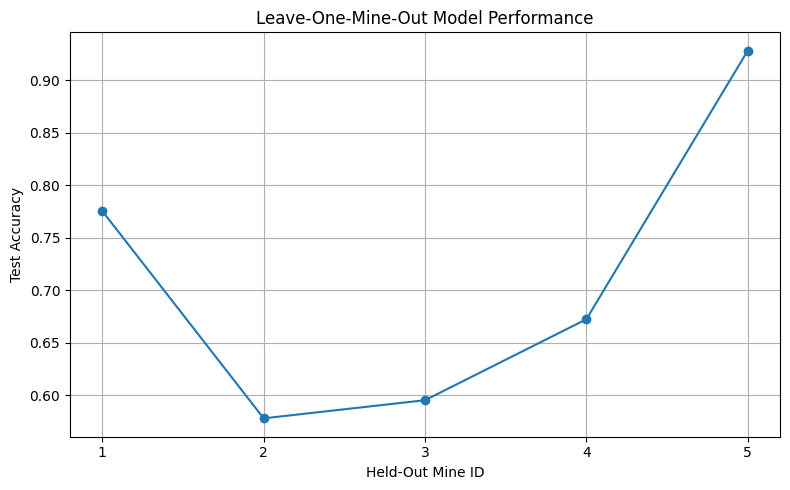

In [5]:
import matplotlib.pyplot as plt

res_df = pd.DataFrame(results)

plt.figure(figsize=(8,5))
plt.plot(res_df["held_out_mine"], res_df["accuracy"], marker='o', linestyle='-')
plt.xlabel("Held-Out Mine ID")
plt.ylabel("Test Accuracy")
plt.title("Leave-One-Mine-Out Model Performance")
plt.xticks(res_df["held_out_mine"])  # ensure each mine ID is shown on x-axis
plt.grid(True)
plt.tight_layout()
plt.show()